In [147]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [148]:
df = pd.read_excel("global petrol price 2026.xlsx")

In [149]:
df.head()

,Country,Region,Price_Per_Liter_USD,Price_Per_Gallon_USD,Previous_Price_USD,Price_Change_Percent,Price_Trend,Price_Level
0,Hong Kong,Asia,4.11,15.56,3.78,8.7,Stable,Very High
1,Singapore,Asia,3.38,12.79,2.84,19.0,Rising Sharply,Very High
2,Netherlands,Europe,2.80,10.60,2.56,9.4,Stable,Very High
3,Denmark,Europe,2.54,9.61,2.26,12.4,Rising,Very High
4,Germany,Europe,2.47,9.35,2.18,13.3,Rising,Very High


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               101 non-null    object 
 1   Region                101 non-null    object 
 2   Price_Per_Liter_USD   101 non-null    float64
 3   Price_Per_Gallon_USD  101 non-null    float64
 4   Previous_Price_USD    101 non-null    float64
 5   Price_Change_Percent  101 non-null    float64
 6   Price_Trend           101 non-null    object 
 7   Price_Level           101 non-null    object 
dtypes: float64(4), object(4)
memory usage: 6.4+ KB


In [151]:
df.describe()

,Price_Per_Liter_USD,Price_Per_Gallon_USD,Previous_Price_USD,Price_Change_Percent
count,101.000000,101.000000,101.000000,101.000000
mean,1.380891,5.227030,1.278911,8.030693
std,0.709434,2.685499,0.645317,14.363076
min,0.010000,0.040000,0.010000,-65.600000
25%,0.850000,3.220000,0.820000,0.000000
50%,1.310000,4.960000,1.200000,5.300000
75%,1.870000,7.080000,1.720000,12.700000
max,4.110000,15.560000,3.780000,55.100000


In [152]:
df.shape

(101, 8)

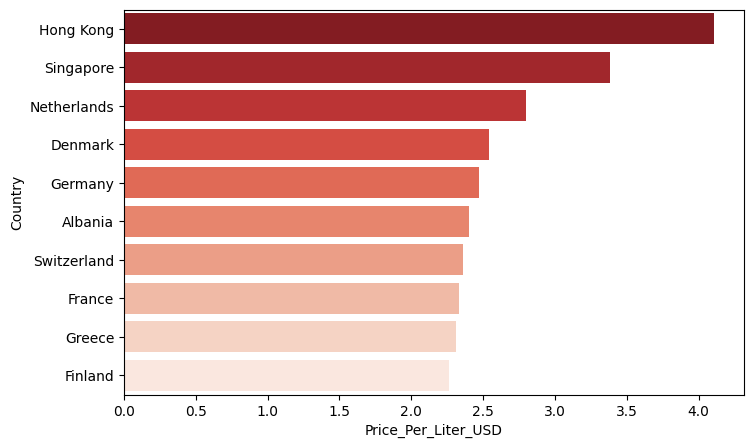

In [153]:
# Top 10 Expensive Countries

top10 = df.sort_values(by = "Price_Per_Liter_USD" , ascending = False).head(10)
plt.figure(figsize = (8,5))
sns.barplot(x = "Price_Per_Liter_USD",
            y= "Country",
            hue = "Country",
            data = top10,
            palette = "Reds_r"
            
           )
plt.show()

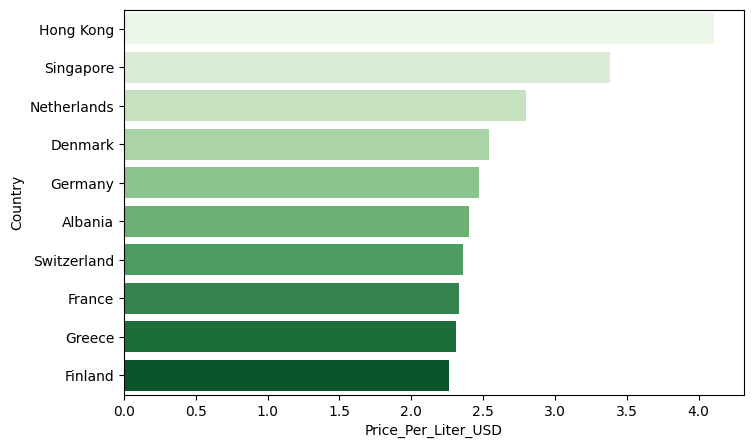

In [154]:
# Bottom 10 chepest Countries

bottom10 = df.sort_values(by = "Price_Per_Liter_USD" , ascending = False).head(10)
plt.figure(figsize = (8,5))
sns.barplot(x = "Price_Per_Liter_USD",
            y= "Country",
            hue = "Country",
            data = bottom10,
            palette = "Greens"
           )
plt.show()

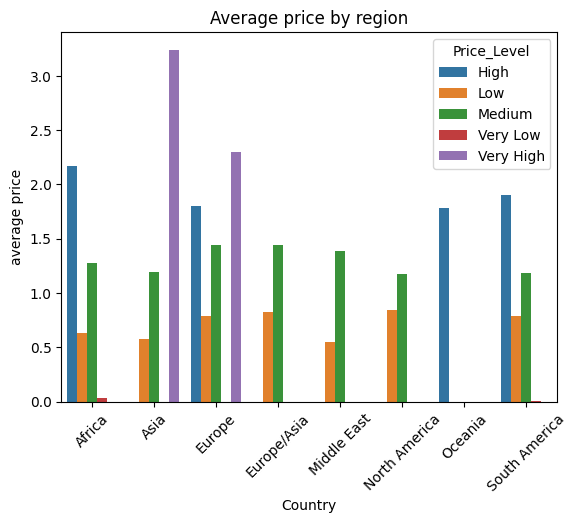

In [162]:
# Region wise average price of fuel
Avg_region = df.groupby(["Region","Price_Level"])["Price_Per_Liter_USD"].mean().reset_index()
sns.barplot(data = Avg_region,
               x = "Region",
               y = "Price_Per_Liter_USD",
               hue = "Price_Level"
              )
plt.xlabel('Country')
plt.ylabel('average price')
plt.title("Average price by region")
plt.xticks(rotation =45)
plt.show()



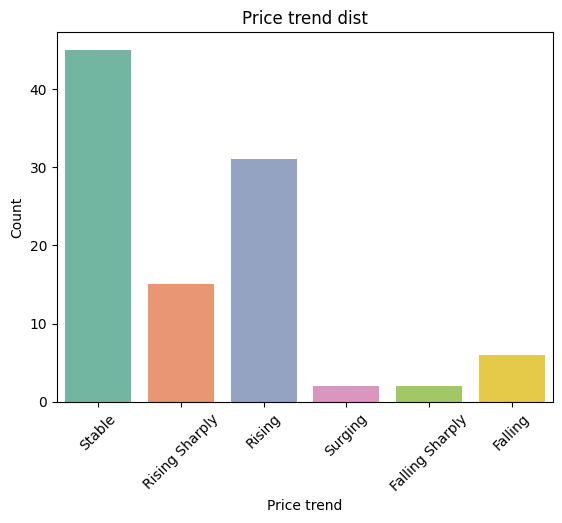

In [163]:
# price trend
sns.countplot(x = "Price_Trend",
              data = df,
              hue =  "Price_Trend",
              palette = "Set2")
plt.xlabel("Price trend")
plt.ylabel("Count")
plt.title("Price trend dist")
plt.xticks(rotation = 45)
plt.show()

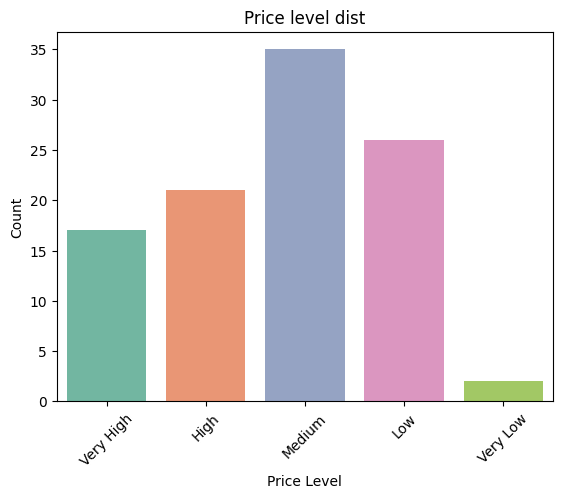

In [71]:
sns.countplot(x = "Price_Level",
              data = df,
              hue =  "Price_Level",
              palette = "Set2")
plt.xlabel("Price Level")
plt.ylabel("Count")
plt.title("Price level dist")
plt.xticks(rotation = 45)
plt.show()

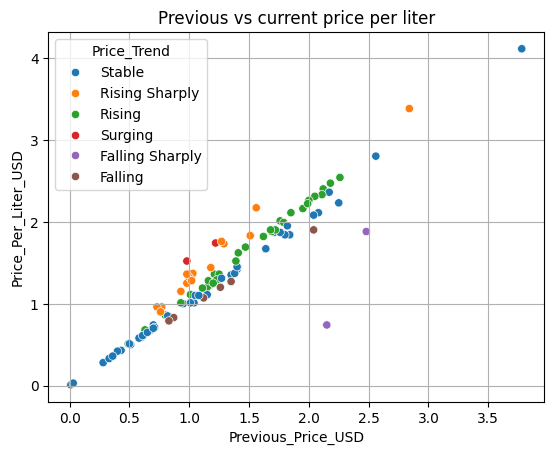

In [164]:
sns.scatterplot(x = "Previous_Price_USD",y = "Price_Per_Liter_USD",data = df,hue = "Price_Trend")
plt.title("Previous vs current price per liter")
plt.grid(True)
plt.show()

<Axes: xlabel='Price_Change_Percent', ylabel='Count'>

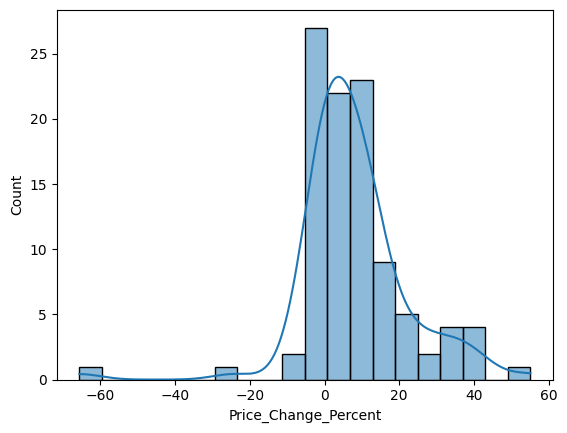

In [84]:
sns.histplot(df["Price_Change_Percent"],bins=20,kde = True)

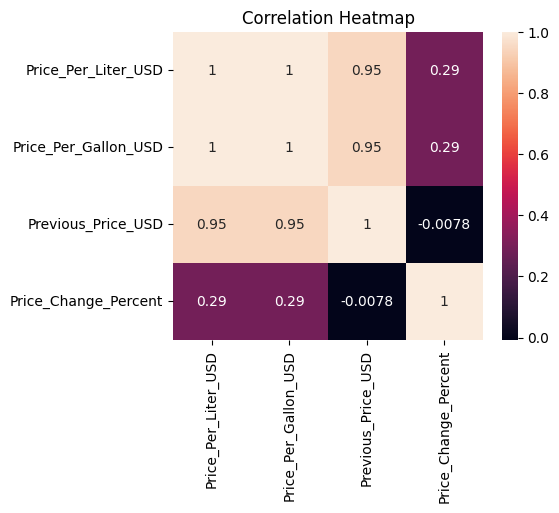

In [97]:
corr =df[['Price_Per_Liter_USD','Price_Per_Gallon_USD','Previous_Price_USD','Price_Change_Percent']].corr()
plt.figure (figsize=(5,4))
sns.heatmap(corr ,annot = True)
plt.title('Correlation Heatmap')
plt.show()

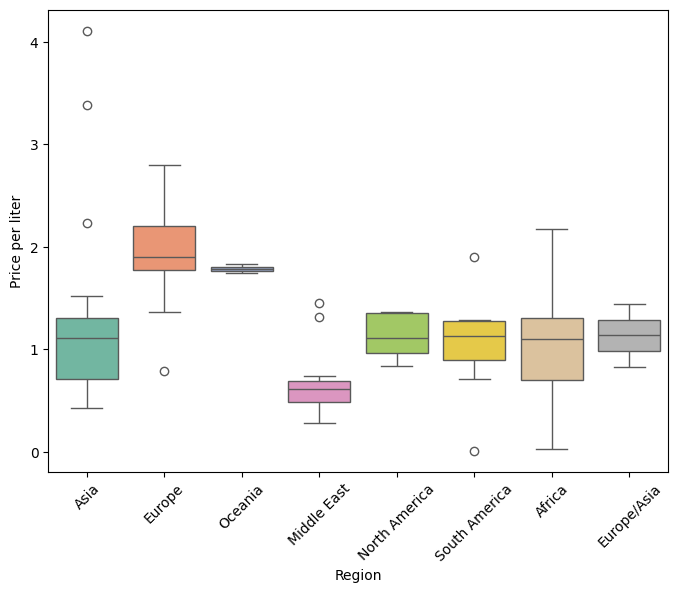

In [111]:
plt.figure(figsize = (8,6))
sns.boxplot(x = "Region",y = "Price_Per_Liter_USD",data = df,hue = "Region",palette = "Set2")
plt.xticks(rotation = 45)
plt.xlabel("Region")
plt.ylabel("Price per liter")
plt.show()

# feature engineering

In [113]:
# Feature and targets

X = df.drop("Price_Level",axis = 1)
y = df["Price_Level"]

In [116]:
le = LabelEncoder()
y = le.fit_transform(y)

In [172]:
# Train-test process
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.2,random_state = 42 )

In [173]:
y_train

array([2, 0, 1, 2, 3, 2, 2, 3, 1, 3, 1, 2, 0, 2, 3, 2, 1, 2, 0, 4, 0, 3,
       1, 2, 0, 0, 4, 0, 2, 2, 3, 0, 3, 0, 2, 3, 1, 3, 2, 3, 2, 1, 1, 1,
       1, 2, 2, 2, 2, 2, 0, 2, 1, 2, 2, 1, 2, 0, 1, 1, 1, 2, 2, 0, 3, 1,
       0, 3, 0, 0, 1, 2, 2, 1, 0, 1, 1, 3, 1, 1])

# preprocessing pipeline

In [174]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['number']).columns

In [175]:
preprocessor = ColumnTransformer([
    ('num',StandardScaler(),num_cols),
    ('car',OneHotEncoder(handle_unknown='ignore'),cat_cols)
])

In [176]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

# Create a pipeline

In [177]:
trained_models ={}

for name,model in models.items():
    pipe = Pipeline(steps =[
        ('preprocessor',preprocessor),
        ('model',model)
    ])

    pipe.fit(X_train,y_train)
    y_pred = pipe.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    trained_models[name] = pipe


===== Logistic Regression =====
Accuracy: 0.7619047619047619
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.60      0.75      0.67         4
           2       0.75      0.75      0.75         8
           3       1.00      0.75      0.86         4

    accuracy                           0.76        21
   macro avg       0.79      0.76      0.77        21
weighted avg       0.78      0.76      0.77        21


===== Decision Tree =====
Accuracy: 0.9523809523809523
              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       1.00      1.00      1.00         4
           2       0.89      1.00      0.94         8
           3       1.00      1.00      1.00         4

    accuracy                           0.95        21
   macro avg       0.97      0.95      0.96        21
weighted avg       0.96      0.95      0.95        21


===== Rando